### MLP with Dropout & Regularization

In [1]:
import torch
import torchvision
from torch import nn
from torch.utils import data
from torchvision import transforms
import matplotlib.pyplot as plt
from utils import *

#### Data Loading & Preprocess

In [2]:
trans = transforms.ToTensor()
mnist_data = torchvision.datasets.FashionMNIST(
    root="./data", train=True, transform=trans, download=True)
mnist_test = torchvision.datasets.FashionMNIST(
    root="./data", train=False, transform=trans, download=True)
len(mnist_data), len(mnist_test)

(60000, 10000)

In [3]:
batch_size = 64
dataloader = data.DataLoader(mnist_data, batch_size=batch_size, shuffle=True)
testloader = data.DataLoader(mnist_test, batch_size=batch_size, shuffle=True)
feature, label = next(iter(dataloader))
feature.shape, label.shape

(torch.Size([64, 1, 28, 28]), torch.Size([64]))

#### MLP

In [4]:
# init model params
num_inputs, num_outputs, num_hiddens1, num_hiddens2 = 784, 10, 256, 256
dropout1, dropout2 = 0.2, 0.5
learning_rate = 0.01

In [5]:
class Net(nn.Module):
    def __init__(self, num_inputs, num_outputs, num_hiddens1, num_hiddens2, dropout1=0.2, dropout2=0.5):
        super().__init__()
        
        self.flatten = nn.Flatten()
        self.layer1 = nn.Linear(in_features=num_inputs, out_features=num_hiddens1)
        self.layer2 = nn.Linear(in_features=num_hiddens1, out_features=num_hiddens2)
        self.layer3 = nn.Linear(in_features=num_hiddens2, out_features=num_outputs)
        
        self.relu = nn.ReLU()
        self.dropout1 = nn.Dropout(dropout1)
        self.dropout2 = nn.Dropout(dropout2)
    
    def forward(self, X):
        X = self.flatten(X)
        H1 = self.relu(self.layer1(X))
        H1 = self.dropout1(H1)
        
        H2 = self.relu(self.layer2(H1))
        H2 = self.dropout2(H2)
        
        out = self.layer3(H2)
        return out

net = Net(num_inputs, num_outputs, num_hiddens1, num_hiddens2)

In [6]:
loss = nn.CrossEntropyLoss(reduction='none')

In [7]:
optimizer = torch.optim.SGD(
    net.parameters(), 
    lr=learning_rate, 
    weight_decay=1e-4)

In [8]:
train_acc, test_acc = train(net, dataloader, loss, optimizer, 10, testloader)

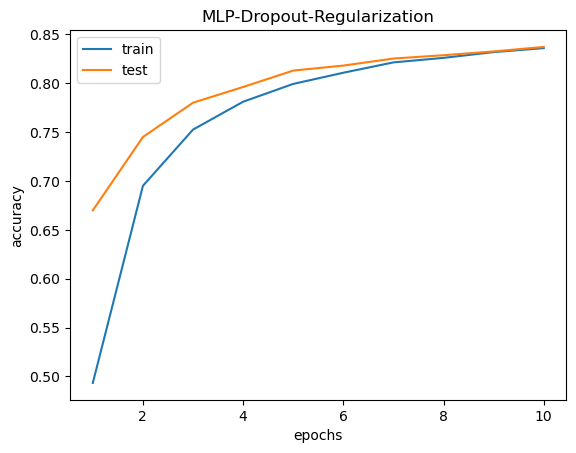

In [9]:
fig, ax = plt.subplots()
ax.set_title("MLP-Dropout-Regularization")
ax.set_xlabel("epochs")
ax.set_ylabel("accuracy")
ax.plot(range(1, 11), train_acc, label="train")
ax.plot(range(1, 11), test_acc, label="test")
ax.legend()
plt.show()

In [10]:
print(test_acc)

[0.6699, 0.745, 0.7801, 0.7962, 0.813, 0.8181, 0.8253, 0.8287, 0.8326, 0.8372]
